# Pricing American Options by Finite Difference 

- Replicating the Finite Difference implementation in {cite:p}`LongstaffSchwartz2001`.
- Replicating the values in Table 1.
- Completely replicating the Table 1, as in the paper (last cell of the code)

## Background

The Black-Scholes PDE for a derivative $V(S,t)$ is:

$$\frac{\partial V}{\partial t} + \frac{1}{2}\sigma^2 S^2 \frac{\partial^2 V}{\partial S^2} + rS\frac{\partial V}{\partial S} - rV = 0$$

**Log-transformation:** Setting $X = \log(S)$ simplifies to constant coefficients:

$$\frac{\partial V}{\partial t} + \frac{1}{2}\sigma^2 \frac{\partial^2 V}{\partial X^2} + \left(r - \frac{1}{2}\sigma^2\right)\frac{\partial V}{\partial X} - rV = 0$$

**Discretization schemes:**
- **European (FTCS):** Forward in time, central in space - explicit scheme
- **American (BTCS):** Backward in time, central in space - implicit scheme with early exercise constraint

For American options, at each time step we enforce: $V \geq \max(K - S, 0)$

In [1]:
import numpy as np
from scipy.stats import norm
from scipy.linalg import lu_factor, lu_solve
import pandas as pd
import matplotlib.pyplot as plt
import time
import sys
sys.path.insert(0, '..')
from utils import bs_put_price

## LSMC Helper Functions

We define the LSMC pricer from {cite:t}`LongstaffSchwartz2001` here for benchmarking the finite difference results.

In [2]:
def simulate_gbm_paths(S0, r, sigma, T, n_steps, n_paths):
    """GBM paths with antithetic sampling (doubles effective paths)."""
    np.random.seed(1)
    dt = T / n_steps
    Z = np.random.randn(n_paths, n_steps)
    Z_all = np.vstack([Z, -Z])  # antithetic pairs
    
    n_total = 2 * n_paths
    S = np.zeros((n_total, n_steps + 1))
    S[:, 0] = S0
    
    for t in range(n_steps):
        S[:, t+1] = S[:, t] * np.exp((r - 0.5*sigma**2)*dt + sigma*np.sqrt(dt)*Z_all[:, t])
    return S


def laguerre_polynomials(x, K):
    """First three weighted Laguerre polynomials, scaled by moneyness."""
    x_scaled = x / K
    exp_term = np.exp(-x_scaled / 2)
    L0 = exp_term
    L1 = exp_term * (1 - x_scaled)
    L2 = exp_term * (1 - 2*x_scaled + x_scaled**2 / 2)
    return L0, L1, L2


def lsmc_american_put(S, K, r, T, n_steps):
    """LSMC American put pricer using Laguerre basis functions."""
    n_paths = S.shape[0]
    dt = T / n_steps
    df = np.exp(-r * dt)
    
    # Cash flow matrix
    cash_flows = np.zeros((n_paths, n_steps + 1))
    cash_flows[:, -1] = np.maximum(K - S[:, -1], 0)
    
    # Backward induction
    for t in range(n_steps - 1, 0, -1):
        payoff = np.maximum(K - S[:, t], 0)
        itm = payoff > 0
        
        if np.sum(itm) > 0:
            X = S[itm, t]
            L0, L1, L2 = laguerre_polynomials(X, K)
            A = np.column_stack([np.ones_like(X), L0, L1, L2])
            
            # Discounted future cash flows
            Y = np.zeros(n_paths)
            for s in range(t+1, n_steps+1):
                Y += cash_flows[:, s] * df**(s-t)
            Y = Y[itm]
            
            # Regression for continuation value
            beta = np.linalg.lstsq(A, Y, rcond=None)[0]
            cont_value = A @ beta
            
            # Exercise decision
            exercise = payoff[itm] >= cont_value
            itm_indices = np.where(itm)[0]
            for i, should_exercise in enumerate(exercise):
                if should_exercise:
                    idx = itm_indices[i]
                    cash_flows[idx, t] = payoff[idx]
                    cash_flows[idx, t+1:] = 0
    
    # Discount to t=0
    option_values = np.zeros(n_paths)
    for i in range(n_paths):
        exercise_times = np.where(cash_flows[i, :] > 0)[0]
        if len(exercise_times) > 0:
            t_ex = exercise_times[0]
            option_values[i] = cash_flows[i, t_ex] * df**t_ex
    
    return np.mean(option_values), np.std(option_values) / np.sqrt(n_paths)

## European Put: Explicit Scheme (FTCS)

For European options, we use an **explicit scheme** (Forward Time, Central Space):
- Known initial condition: $V(S, T) = \max(K - S, 0)$
- March forward in time from $t=0$ to $t=T$
- Boundary conditions: $V \to Ke^{-r(T-t)}$ as $S \to 0$, and $V \to 0$ as $S \to \infty$

In [3]:
def fd_european_put(S0, K, r, sigma, T, Nx=1000, Nt=40000, L=10):
    """European put via explicit finite difference (FTCS)."""
    start = time.perf_counter()
    h = L / Nx  # spatial step
    k = T / Nt  # time step
    
    # Finite difference matrices for first and second derivatives
    T1 = np.diag([1] * (Nx-2), 1) - np.diag([1] * (Nx-2), -1)
    T2 = -2 * np.diag([1] * (Nx-1)) + np.diag([1] * (Nx-2), 1) + np.diag([1] * (Nx-2), -1)
    
    # Evolution matrix
    F = ((1 - r*k) * np.diag([1] * (Nx-1)) 
         + 0.5 * k * sigma**2 / h**2 * T2 
         + k * (r - 0.5*sigma**2) / (2*h) * T1)

    # Log-space grid centered at log(S0)
    mvec = np.linspace(np.log(S0) - L/2 + h, np.log(S0) + L/2 - h, Nx-1)
    
    # Initial condition: put payoff at t=0
    U = np.zeros((Nx-1, Nt+1))
    U[:, 0] = np.maximum(K - np.exp(mvec), 0)
    
    # Forward time-stepping
    for i in range(Nt):
        time2mat = i * k
        p = np.zeros(Nx-1)
        # Left BC: as S -> 0, put value -> Ke^{-r(T-t)}
        p[0] = (0.5 * k * sigma**2 / h**2 - k * (r - 0.5*sigma**2) / (2*h)) * K * np.exp(-r * time2mat)
        U[:, i+1] = F @ U[:, i] + p
    
    runtime = time.perf_counter() - start
    price = np.interp(np.log(S0), mvec, U[:, Nt])
    return price, runtime

## American Put: Implicit Scheme (BTCS)

For American options, we use an **implicit scheme** (Backward Time, Central Space):
- Known terminal condition: $V(S, T) = \max(K - S, 0)$
- March backward in time from $t=T$ to $t=0$
- At each step, solve linear system then enforce early exercise: $V \geq \max(K - S, 0)$
- Uses LU factorization for efficient repeated solves

In [4]:
def fd_american_put(S0, K, r, sigma, T, Nx=1000, Nt=40000, L=10):
    """American put via implicit finite difference (BTCS) with early exercise."""
    start = time.perf_counter()
    h = L / Nx  # spatial step
    k = T / Nt  # time step

    # Finite difference matrices
    T1 = np.diag([1] * (Nx-2), 1) - np.diag([1] * (Nx-2), -1)
    T2 = -2 * np.diag([1] * (Nx-1)) + np.diag([1] * (Nx-2), 1) + np.diag([1] * (Nx-2), -1)

    # Log-space grid centered at log(S0)
    mvec = np.linspace(np.log(S0) - L/2 + h, np.log(S0) + L/2 - h, Nx-1)
    stock_prices = np.exp(mvec)

    # Implicit scheme matrix: M * V_new = V_old + boundary terms
    I = np.eye(Nx-1)
    M = ((1 + r*k) * I 
         - 0.5 * k * sigma**2 / h**2 * T2 
         - k * (r - 0.5*sigma**2) / (2*h) * T1)
    lu, piv = lu_factor(M)

    # Terminal condition
    V = np.maximum(K - stock_prices, 0)

    # Backward induction with early exercise
    for n in range(Nt-1, -1, -1):
        b = V.copy()
        # Left BC: as S -> 0, American put -> K
        b[0] = (0.5 * k * sigma**2 / h**2 - k * (r - 0.5*sigma**2) / (2*h)) * K
        
        # Solve for continuation value
        V_cont = lu_solve((lu, piv), b)
        
        # Early exercise constraint
        V = np.maximum(V_cont, np.maximum(K - stock_prices, 0))

    runtime = time.perf_counter() - start
    price = np.interp(np.log(S0), mvec, V)
    return price, runtime

### Define table replicating functions

In [5]:
def replicate_table1_european():
    """ Replicate European put values from Table 1 using FD method
    Compare with Black-Scholes closed form
    - noting early ex. values are also negative as this comparison is for 2 EU-put options
    """
    # Fixed parameters from the paper
    K = 40
    r = 0.06
    
    # Parameters from Table 1
    params = [
        (36, 0.20, 1), (36, 0.20, 2), (36, 0.40, 1), (36, 0.40, 2),
        (38, 0.20, 1), (38, 0.20, 2), (38, 0.40, 1), (38, 0.40, 2),
        (40, 0.20, 1), (40, 0.20, 2), (40, 0.40, 1), (40, 0.40, 2),
        (42, 0.20, 1), (42, 0.20, 2), (42, 0.40, 1), (42, 0.40, 2),
        (44, 0.20, 1), (44, 0.20, 2), (44, 0.40, 1), (44, 0.40, 2)
    ]
    
    print("\nFinite Difference European Put Pricing")
    print("")
    print(f"{'S':>4} {'vol':>4} {'T':>3} | {'FD European':>12} | {'BS European':>12} | {'Difference':>10} | {'Runtime':>10}")
    print("-"*70)

    results = []
    for S0, sigma, T in params:
        # Calculate FD price
        fd_price, runtime_eu = fd_european_put(S0, K, r, sigma, T)
        # Calculate Black-Scholes price
        bs_price = bs_put_price(S0, K, r, sigma, T)
        # Calculate difference
        diff = fd_price - bs_price
        
        # Display results
        print(f"{S0:>4} {sigma:>5.2f} {T:>3}   "
              f"{fd_price:>12.4f}   "
              f"{bs_price:>12.4f}   "
              f"{diff:>10.6f}   "
              f"{runtime_eu:>8.4f}")
        
        results.append({
            'S': S0,
            'sigma': sigma,
            'T': T,
            'FD_European': fd_price,
            'BS_European': bs_price,
            'Early ex. value': diff,
            'Runtime': runtime_eu
        })
    
    df_results = pd.DataFrame(results)
    
    return df_results

df_results1 = replicate_table1_european()


Finite Difference European Put Pricing

   S  vol   T |  FD European |  BS European | Difference |    Runtime
----------------------------------------------------------------------
  36  0.20   1         3.8445         3.8443     0.000170     5.5026
  36  0.20   2         3.7631         3.7630     0.000087     5.6772
  36  0.40   1         6.7114         6.7114     0.000045     6.2496
  36  0.40   2         7.7001         7.7000     0.000044     5.2664
  38  0.20   1         2.8515         2.8519    -0.000441     5.7916
  38  0.20   2         2.9903         2.9906    -0.000300     5.5708
  38  0.40   1         5.8341         5.8343    -0.000217     5.5067
  38  0.40   2         6.9787         6.9788    -0.000128     6.1348
  40  0.20   1         2.0655         2.0664    -0.000911     6.1208
  40  0.20   2         2.3553         2.3559    -0.000594     6.1544
  40  0.40   1         5.0592         5.0596    -0.000439     5.9834
  40  0.40   2         6.3257         6.3260    -0.000273  

In [6]:
def replicate_table1():
    """ Replication of Table 1 format from the paper   """
    # Fixed parameters
    K = 40
    r = 0.06
    
    # Parameters
    params = [
        (36, 0.20, 1), (36, 0.20, 2), (36, 0.40, 1), (36, 0.40, 2),
        (38, 0.20, 1), (38, 0.20, 2), (38, 0.40, 1), (38, 0.40, 2),
        (40, 0.20, 1), (40, 0.20, 2), (40, 0.40, 1), (40, 0.40, 2),
        (42, 0.20, 1), (42, 0.20, 2), (42, 0.40, 1), (42, 0.40, 2),
        (44, 0.20, 1), (44, 0.20, 2), (44, 0.40, 1), (44, 0.40, 2)
    ]
    
    print("\nTable 1: American put values, closed form European and early exercise value")
    print("")
    print("                     American       BS European    Early Ex.    Runtime")
    print("Price    vol    T    Put            Put            value")
    print("-" * 75)
    
    results = []
    for S0, sigma, T in params:
        european = bs_put_price(S0, K, r, sigma, T)
        american, runtime_am = fd_american_put(S0, K, r, sigma, T)
        ex_value = american - european
        
        print(f"{S0:3.0f}     {sigma:4.2f}    {T:1.0f}   "
                f"{american:7.4f}        {european:7.4f}         {ex_value:6.4f}         {runtime_am:6.4f}")
    
    results.append({
            'S': S0,
            'vol': sigma,
            'T': T,
            'FD_American': american,
            'BS_European': european,
            'Early exercise': ex_value,
            'Runtime': runtime_am
        })
    df_results = pd.DataFrame(results)
    
    return df_results

df_results3 = replicate_table1()


Table 1: American put values, closed form European and early exercise value

                     American       BS European    Early Ex.    Runtime
Price    vol    T    Put            Put            value
---------------------------------------------------------------------------
 36     0.20    1    4.4860         3.8443         0.6417         20.7117
 36     0.20    2    4.8477         3.7630         1.0847         20.1554
 36     0.40    1    7.1087         6.7114         0.3973         18.7160
 36     0.40    2    8.5140         7.7000         0.8139         17.9491
 38     0.20    1    3.2563         2.8519         0.4044         18.9162
 38     0.20    2    3.7507         2.9906         0.7602         19.8062
 38     0.40    1    6.1542         5.8343         0.3198         19.3326
 38     0.40    2    7.6746         6.9788         0.6958         22.7733
 40     0.20    1    2.3185         2.0664         0.2521         23.1768
 40     0.20    2    2.8892         2.3559         

## Observations

The FD American pricer takes ~15 seconds per option due to the fine grid (Nx=1000, Nt=40000).

**Potential improvements:**
- Use the COS method for American options (see next notebook)
- Implement in C++ for better performance
- Use sparse matrix operations

#### Convergence analysis

Computing LSMC benchmark value with 1 million paths...
LSMC benchmark: 4.478278 (s.e. = 0.002902)

Testing FD convergence...
Testing LSMC standard error convergence...


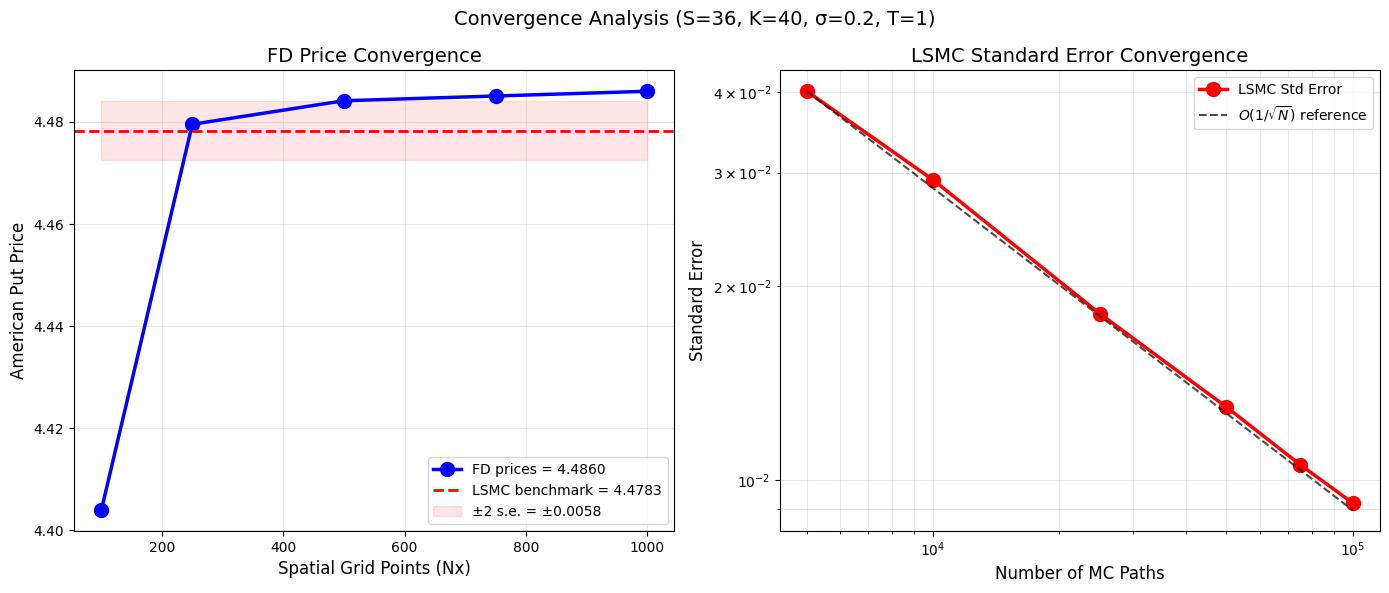


CONVERGENCE SUMMARY
FD (Nx=1000, Nt=40000): 4.486006
LSMC benchmark:         4.478278 ± 0.002902
Difference:             0.007728

FD within 2 s.e. of LSMC: False


In [12]:
def convergence_plot():
    """
    Convergence analysis: FD grid refinement and LSMC standard error.
    
    - Left: FD price convergence as grid is refined
    - Right: LSMC standard error decay (should follow O(1/√N))
    """
    # Parameters
    S0, K, r, sigma, T = 36, 40, 0.06, 0.20, 1
    
    # Get LSMC benchmark with very high accuracy
    print("Computing LSMC benchmark value with 1 million paths...")
    np.random.seed(1)
    S_paths = simulate_gbm_paths(S0, r, sigma, T, 50, 500000)  # 1mil paths total
    lsmc_value, lsmc_se = lsmc_american_put(S_paths, K, r, T, 50)
    print(f"LSMC benchmark: {lsmc_value:.6f} (s.e. = {lsmc_se:.6f})")
    
    # Test FD convergence
    print("\nTesting FD convergence...")
    grid_sizes = [(100, 1000), (250, 5000), (500, 10000), (750, 20000), (1000, 40000)]
    nx_vals = [g[0] for g in grid_sizes]
    fd_vals = [fd_american_put(S0, K, r, sigma, T, Nx=Nx, Nt=Nt)[0] for Nx, Nt in grid_sizes]
    
    # Test LSMC standard error convergence
    print("Testing LSMC standard error convergence...")
    n_paths_list = [5000, 10000, 25000, 50000, 75000, 100000]
    lsmc_ses = []
    
    for n_paths in n_paths_list:
        np.random.seed(1)
        S_paths = simulate_gbm_paths(S0, r, sigma, T, 50, n_paths//2)
        se = lsmc_american_put(S_paths, K, r, T, 50)[1]
        lsmc_ses.append(se)
    
    # Create subplots
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))
    
    # --- Left: FD price convergence ---
    ax1.plot(nx_vals, fd_vals, 'bo-', markersize=10, linewidth=2.5, label=f'FD prices = {fd_vals[-1]:.4f}')
    ax1.axhline(y=lsmc_value, color='red', linestyle='--', linewidth=2, 
                label=f'LSMC benchmark = {lsmc_value:.4f}')
    ax1.fill_between([nx_vals[0], nx_vals[-1]], 
                     lsmc_value - 2*lsmc_se, lsmc_value + 2*lsmc_se,
                     color='red', alpha=0.1, label=f'±2 s.e. = ±{2*lsmc_se:.4f}')

    ax1.set_xlabel('Spatial Grid Points (Nx)', fontsize=12)
    ax1.set_ylabel('American Put Price', fontsize=12)
    ax1.set_title('FD Price Convergence', fontsize=14)
    ax1.grid(True, alpha=0.3)
    ax1.legend(fontsize=10, loc='lower right')
    
    # --- Right: LSMC standard error convergence ---
    ax2.loglog(n_paths_list, lsmc_ses, 'ro-', markersize=10, linewidth=2.5, label='LSMC Std Error')
    
    # Add O(1/√N) reference line
    n_ref = np.array([5000, 100000])
    se_ref = lsmc_ses[0] * np.sqrt(n_paths_list[0] / n_ref)
    ax2.loglog(n_ref, se_ref, 'k--', linewidth=1.5, alpha=0.7, label=r'$O(1/\sqrt{N})$ reference')
    
    ax2.set_xlabel('Number of MC Paths', fontsize=12)
    ax2.set_ylabel('Standard Error', fontsize=12)
    ax2.set_title('LSMC Standard Error Convergence', fontsize=14)
    ax2.grid(True, alpha=0.3, which='both')
    ax2.legend(fontsize=10)
    
    plt.suptitle(f'Convergence Analysis (S={S0}, K={K}, σ={sigma}, T={T})', fontsize=14)
    plt.tight_layout()
    plt.show()
    
    # Summary
    print(f"\n{'='*50}")
    print("CONVERGENCE SUMMARY")
    print(f"{'='*50}")
    print(f"FD (Nx=1000, Nt=40000): {fd_vals[-1]:.6f}")
    print(f"LSMC benchmark:         {lsmc_value:.6f} ± {lsmc_se:.6f}")
    print(f"Difference:             {abs(fd_vals[-1] - lsmc_value):.6f}")
    print(f"\nFD within 2 s.e. of LSMC: {abs(fd_vals[-1] - lsmc_value) < 2*lsmc_se}")

convergence_plot()

In [11]:
def generate_table1(): # Generates the complete Table 1
    """ Generate complete Table 1 
    Want to show: 
    - Use overkilled LSMC params to get as precise as possible price
    - Does FD-price tend to that value?
        - Plot suggests otherwise
        - In Table there is a slight inaccuracy in AM-price [need to correct]
    """
    # Fixed parameters
    K = 40
    r = 0.06
    
    # Table parameters
    params = [
        (36, 0.20, 1), (36, 0.20, 2), (36, 0.40, 1), (36, 0.40, 2),
        (38, 0.20, 1), (38, 0.20, 2), (38, 0.40, 1), (38, 0.40, 2),
        (40, 0.20, 1), (40, 0.20, 2), (40, 0.40, 1), (40, 0.40, 2),
        (42, 0.20, 1), (42, 0.20, 2), (42, 0.40, 1), (42, 0.40, 2),
        (44, 0.20, 1), (44, 0.20, 2), (44, 0.40, 1), (44, 0.40, 2)
    ]
    
    results = []
    
    for S0, sigma, T in params:
        # Closed form EU
        european = bs_put_price(S0, K, r, sigma, T)
        
        # FD AM put pricer
        american_fd = fd_american_put(S0, K, r, sigma, T)[0]
        early_ex_fd = american_fd - european
        
        # LSMC-pricer
        np.random.seed(1)
        n_steps = int(T * 50)
        S_paths = simulate_gbm_paths(S0, r, sigma, T, n_steps, 50000) # as in paper
        american_lsmc, se_lsmc = lsmc_american_put(S_paths, K, r, T, n_steps)
        early_ex_lsmc = american_lsmc - european
        
        # Difference in early exercise 
        diff = early_ex_lsmc - early_ex_fd
        
        results.append({
            'S': S0, 'sigma': sigma, 'T': T,
            'FD_American': american_fd, 'European': european, 'FD_Early_Ex': early_ex_fd,
            'LSMC_American': american_lsmc, 'SE': se_lsmc, 'LSMC_Early_Ex': early_ex_lsmc,
            'Difference': diff
        })
    
    df = pd.DataFrame(results)
    
    return print(df)

# When we run this is for each triplet in params it computes the LSMC-overkilled which takes too long to compute
#generate_table1()